In [1]:
import os 
import cv2
import torch
import torchvision
import torchinfo 
from torchvision import transforms 
from torch.utils.data import Dataset,DataLoader
import matplotlib.pyplot as plt
import numpy as np 
from tqdm import tqdm
from torchinfo import summary
from torch import nn,optim
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix

In [2]:
import sys
sys.executable

'c:\\Users\\S\\Desktop\\labmentix(AIML internship)\\Aerial object detection and classification\\khush\\Scripts\\python.exe'

In [3]:
file=os.listdir("./Data/train/bird")
file[:5]

['000596bc75926abe_jpg.rf.49cf79ededcab42c160f599b1104f421.jpg',
 '000596bc75926abe_jpg.rf.dd331440f1cc9338d6c4ff82cd7200d6.jpg',
 '000712bbe0a4844f_jpg.rf.39ceec229b870fda18f3d8fb1f09af87.jpg',
 '000712bbe0a4844f_jpg.rf.8e869da274a69f828a31be97b34d8a32.jpg',
 '000f6e054dde03c8_jpg.rf.f6bc4d3376c3235f3c31171382403232.jpg']

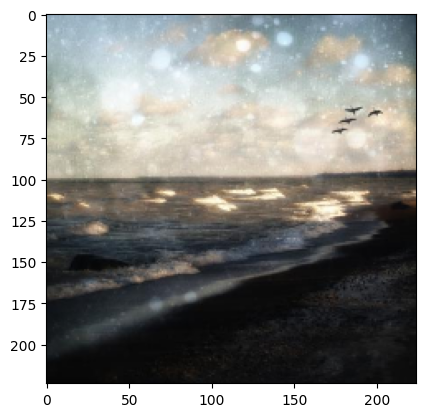

In [4]:
path=os.path.join("./Data/train/bird", file[0])
img=cv2.imread(path)
img=cv2.resize(img,dsize=(224,224))
img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
plt.imshow(img)

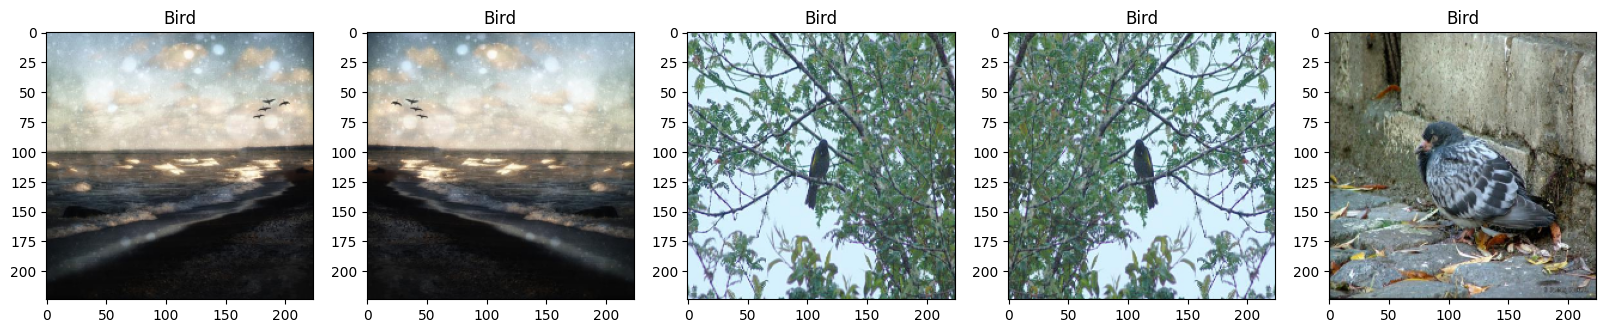

In [5]:
fig,axs=plt.subplots(1,5,figsize=(20,20))
for i in range(5):
    path=os.path.join("./Data/train/bird", file[i])
    img=cv2.imread(path)
    img=cv2.resize(img,dsize=(224,224))
    img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    axs[i].imshow(img)
    axs[i].set_title("Bird")

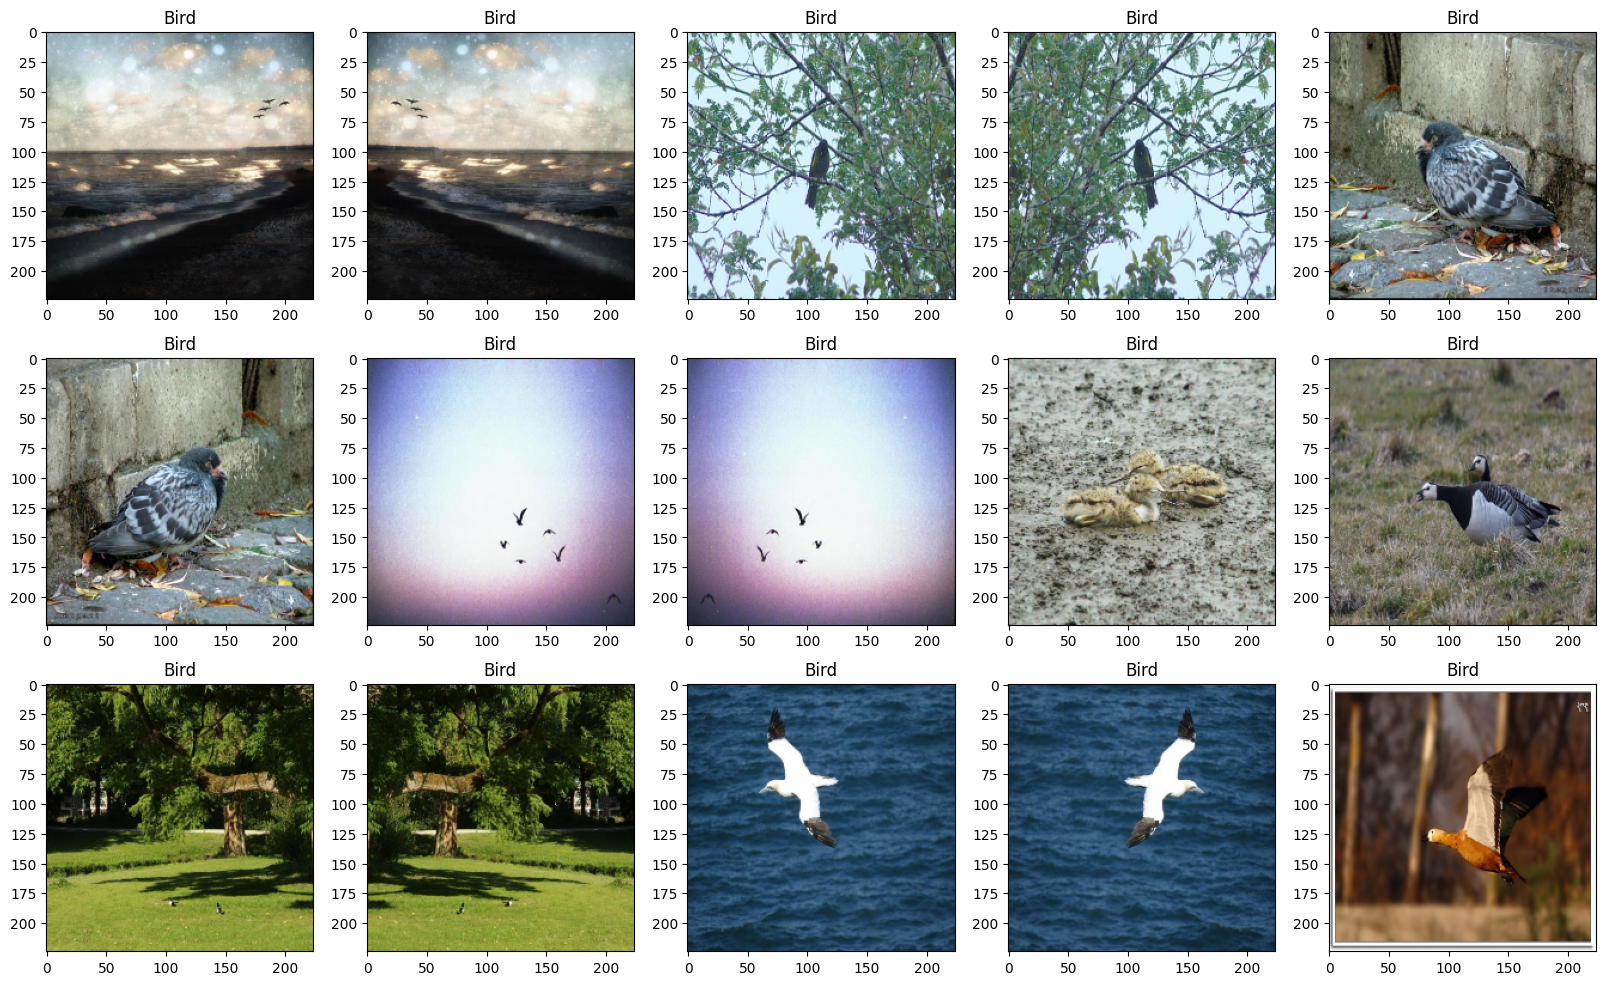

In [6]:
plt.figure(figsize=(20,12))
k=0
for i in range(3):
    for j in range(5):
        plt.subplot(3,5,k+1)
        path=os.path.join("./Data/train/bird", file[k])
        img=cv2.imread(path)
        img=cv2.resize(img,dsize=(224,224))
        img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
        plt.imshow(img)
        plt.title("Bird")
        k += 1

In [7]:
files=os.listdir("./Data/train/drone")
files[:5]

['foto00117_png.rf.3fa4f4dbcfefb2e1eb9091247853f528.jpg',
 'foto00117_png.rf.f5e1d1a0734d247c460138e6b920e9ef.jpg',
 'foto00204_png.rf.092f4af62cef89fecc4f17dfd8353f6e.jpg',
 'foto00204_png.rf.c267ebe9c3475c52aa8daa9c8c6ab52a.jpg',
 'foto00233_png.rf.6adb431a56bde9034be4e4b7b34af083.jpg']

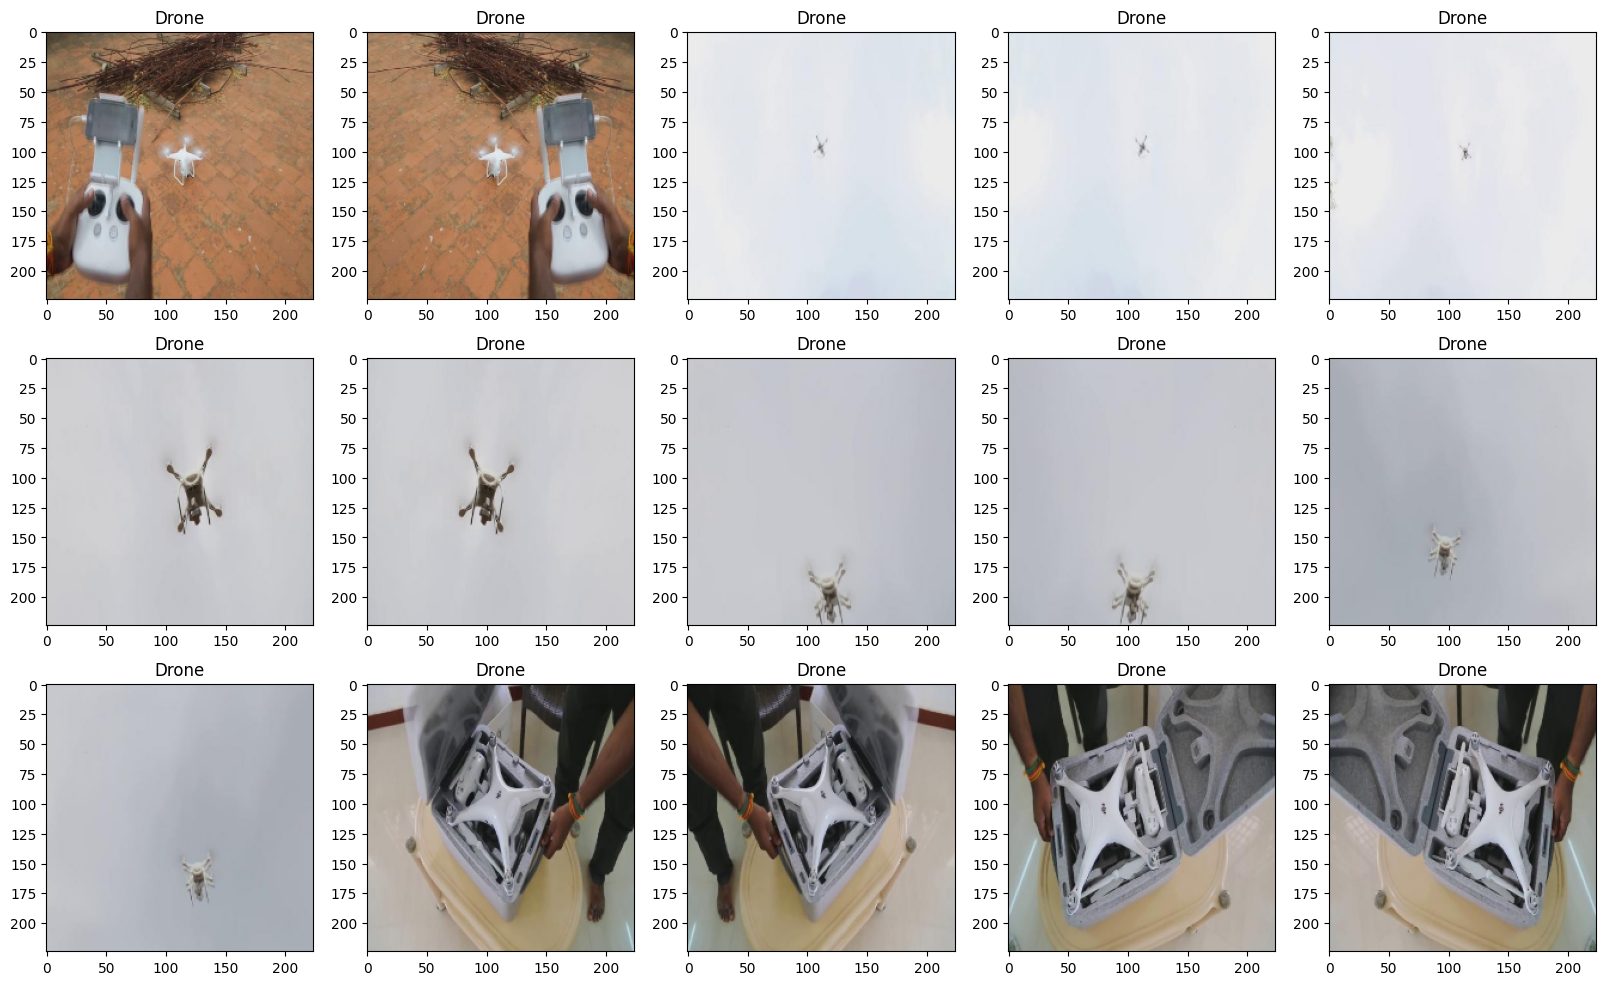

In [8]:
plt.figure(figsize=(20,12))
k=0
for i in range(3):
    for j in range(5):
        plt.subplot(3,5,k+1)
        path=os.path.join("./Data/train/drone", files[k])
        img=cv2.imread(path)
        img=cv2.resize(img,dsize=(224,224))
        img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
        plt.imshow(img)
        plt.title("Drone")
        k += 1

In [9]:
import glob as glob
from concurrent.futures import ThreadPoolExecutor,as_completed


def process_image(path):
    img=cv2.imread(path)
    try:
        if img is not None:
            img=cv2.resize(img,dsize=(224,224))
            img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
            return img
        else:
            print(f"Error: Unable to read image at {path}")
            return None
    except Exception as e:
        print(f"Error processing image at {path}: {e}")
        return None
    
    except cv2.error as e:
        print(f"OpenCV error processing image at {path}: {e}")
        return None
    
def load_images(path):
    images=[]
    file_pattern=os.path.join(path,"*.jpg")
    filenames=glob.glob(file_pattern)
    
    with ThreadPoolExecutor(max_workers=8) as executor:
        future_to_filename = {executor.submit(process_image, filename): filename for filename in filenames[0: int(1*len(filenames))]}
        for future in tqdm(as_completed(future_to_filename), total=len(filenames)):
            result = future.result()
            if result is not None:
                images.append(result)

    return np.array(images)

In [10]:
bird_train=load_images("./Data/train/bird")
drone_train=load_images("./Data/train/drone")
bird_test=load_images("./Data/test/bird")
drone_test=load_images("./Data/test/drone")
bird_val=load_images("./Data/valid/bird")
drone_val=load_images("./Data/valid/drone")
bird_train.shape,drone_train.shape,bird_test.shape,drone_test.shape,bird_val.shape,drone_val.shape

100%|██████████| 225/225 [00:00<00:00, 1198.43it/s]


((1414, 224, 224, 3),
 (1248, 224, 224, 3),
 (121, 224, 224, 3),
 (94, 224, 224, 3),
 (217, 224, 224, 3),
 (225, 224, 224, 3))

In [11]:
os.makedirs("./Data/numpy", exist_ok=True)
np.save("./Data/numpy/bird_train.npy", bird_train)
np.save("./Data/numpy/drone_train.npy", drone_train)
np.save("./Data/numpy/bird_test.npy", bird_test)
np.save("./Data/numpy/drone_test.npy", drone_test)
np.save("./Data/numpy/bird_val.npy", bird_val)
np.save("./Data/numpy/drone_val.npy", drone_val)

In [12]:
birdtrain=np.load("./Data/numpy/bird_train.npy")
birdtest=np.load("./Data/numpy/bird_test.npy")
birdval=np.load("./Data/numpy/bird_val.npy")
dronetrain=np.load("./Data/numpy/drone_train.npy")
dronetest=np.load("./Data/numpy/drone_test.npy")    
droneval=np.load("./Data/numpy/drone_val.npy")
print(f"Bird Train shape: {birdtrain.shape}\nBird_test : {birdtest.shape}\nBird_val : {birdval.shape}\nDrone_train : {dronetrain.shape}\nDrone_test : {dronetest.shape}\nDrone_val : {droneval.shape}")

Bird Train shape: (1414, 224, 224, 3)
Bird_test : (121, 224, 224, 3)
Bird_val : (217, 224, 224, 3)
Drone_train : (1248, 224, 224, 3)
Drone_test : (94, 224, 224, 3)
Drone_val : (225, 224, 224, 3)


In [13]:
birdtrainlabel=np.array([0]*birdtrain.shape[0]).reshape(-1,1)
birdtestlabel=np.array([0]*len(birdtest)).reshape(-1,1)
birdvallabel=np.array([0]*len(birdval)).reshape(-1,1)
dronetrainlabel=np.array([1]*dronetrain.shape[0]).reshape(-1,1)
dronetestlabel=np.array([1]*len(dronetest)).reshape(-1,1)
dronevallabel=np.array([1]*len(droneval)).reshape(-1,1)
print(f"Bird Train label shape: {birdtrainlabel.shape}\nBird_test label shape : {birdtestlabel.shape}\nBird_val label shape : {birdvallabel.shape}\nDrone_train label shape : {dronetrainlabel.shape}\nDrone_test label shape : {dronetestlabel.shape}\nDrone_val label shape : {dronevallabel.shape}")

Bird Train label shape: (1414, 1)
Bird_test label shape : (121, 1)
Bird_val label shape : (217, 1)
Drone_train label shape : (1248, 1)
Drone_test label shape : (94, 1)
Drone_val label shape : (225, 1)


In [14]:
np.concatenate([birdtrainlabel, dronetrainlabel], axis=0).shape,np.concatenate([birdtrain, dronetrain], axis=0).shape

((2662, 1), (2662, 224, 224, 3))

In [15]:
x_train=np.concatenate([birdtrain, dronetrain], axis=0)
y_train=np.concatenate([birdtrainlabel, dronetrainlabel], axis=0)
x_val=np.concatenate([birdval, droneval], axis=0)
y_val=np.concatenate([birdvallabel, dronevallabel], axis=0)
x_test=np.concatenate([birdtest,dronetest],axis=0)
y_test=np.concatenate([birdtestlabel,dronetestlabel],axis=0)
print(f"x_train shape : {x_train.shape}\ny_train shape : {y_train.shape}\nx_val shape : {x_val.shape}\ny_val shape : {y_val.shape}\nx_test shape : {x_test.shape}\ny_test shape : {y_test.shape}")

x_train shape : (2662, 224, 224, 3)
y_train shape : (2662, 1)
x_val shape : (442, 224, 224, 3)
y_val shape : (442, 1)
x_test shape : (215, 224, 224, 3)
y_test shape : (215, 1)


In [16]:
# x_train.mean(axis=(0,1,2))/255,x_test.mean(axis=(0,1,2))/255,x_val.mean(axis=(0,1,2))/255

In [17]:
# x_train.std(axis=(0,1,2))/255,x_test.std(axis=(0,1,2))/255,x_val.std(axis=(0,1,2))/255

In [18]:
training_train_transforms=transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.2),
        transforms.RandomRotation(20),
        transforms.RandomGrayscale(p=0.2),
        transforms.Normalize(mean=[0.55566122, 0.5696501 , 0.53595315],std=[0.29024144, 0.28019984, 0.31316953])
    ]
)

In [19]:
training_validation_transforms=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.55566122, 0.5696501 , 0.53595315],std=[0.29024144, 0.28019984, 0.31316953])
])

In [20]:
class Data(Dataset):
    def __init__(self,image,label,transforms=None):
        super().__init__()
        self.image=image
        self.label=torch.tensor(label)
        self.transforms=transforms
    
    def __getitem__(self,index):
        label=self.label[index]
        if self.transforms:
            img=self.transforms(self.image[index])
        return (img,label)
    
    def __len__(self):
        return len(self.image)

In [21]:
traindata=Data(x_train,y_train,training_train_transforms)

In [22]:
Data(x_train,y_train,training_train_transforms)[150]

(tensor([[[-1.9145, -1.9145, -1.9145,  ..., -1.9145, -1.9145, -1.9145],
          [-1.9145, -1.9145, -1.9145,  ..., -1.9145, -1.9145, -1.9145],
          [-1.9145, -1.9145, -1.9145,  ..., -1.9145, -1.9145, -1.9145],
          ...,
          [-1.9145, -1.9145, -1.9145,  ..., -1.9145, -1.9145, -1.9145],
          [-1.9145, -1.9145, -1.9145,  ..., -1.9145, -1.9145, -1.9145],
          [-1.9145, -1.9145, -1.9145,  ..., -1.9145, -1.9145, -1.9145]],
 
         [[-2.0330, -2.0330, -2.0330,  ..., -2.0330, -2.0330, -2.0330],
          [-2.0330, -2.0330, -2.0330,  ..., -2.0330, -2.0330, -2.0330],
          [-2.0330, -2.0330, -2.0330,  ..., -2.0330, -2.0330, -2.0330],
          ...,
          [-2.0330, -2.0330, -2.0330,  ..., -2.0330, -2.0330, -2.0330],
          [-2.0330, -2.0330, -2.0330,  ..., -2.0330, -2.0330, -2.0330],
          [-2.0330, -2.0330, -2.0330,  ..., -2.0330, -2.0330, -2.0330]],
 
         [[-1.7114, -1.7114, -1.7114,  ..., -1.7114, -1.7114, -1.7114],
          [-1.7114, -1.7114,

In [23]:
testdata=Data(x_val,y_val,training_validation_transforms)
Data(x_val,y_val,training_validation_transforms)[150]

(tensor([[[-0.5633, -0.5228, -0.6579,  ..., -0.0229, -0.2120, -0.4552],
          [-0.5498, -0.7660, -0.7930,  ...,  0.1798, -0.0634, -0.3336],
          [-0.6174, -0.8201, -1.0227,  ...,  0.3284,  0.1257, -0.1715],
          ...,
          [-1.4416, -1.4416, -1.4010,  ...,  1.0445,  0.3419, -0.9822],
          [-1.4146, -1.4281, -1.4146,  ...,  1.1526,  0.6122, -0.5904],
          [-1.3740, -1.4146, -1.4146,  ...,  1.1526,  0.9229,  0.2068]],
 
         [[-0.6335, -0.5775, -0.7034,  ...,  0.0103, -0.1016, -0.2416],
          [-0.6195, -0.8294, -0.8574,  ...,  0.2483,  0.0943, -0.0736],
          [-0.7174, -0.9274, -1.0953,  ...,  0.4442,  0.3602,  0.1643],
          ...,
          [-1.7531, -1.7391, -1.7111,  ...,  1.3119,  0.5982, -0.7874],
          [-1.7111, -1.7251, -1.7111,  ...,  1.3539,  0.7801, -0.4935],
          [-1.6691, -1.7111, -1.7111,  ...,  1.2839,  1.0180,  0.2483]],
 
         [[-0.6094, -0.5844, -0.7347,  ...,  0.3297,  0.2671,  0.1669],
          [-0.5969, -0.8098,

##### Here we dont use sample in DataLoader instead use shuffle because the target label is balanced if there is imbalance in class label use sample for handling the class imbalance problem

In [24]:
traindataloader=DataLoader(
    dataset=traindata,
    batch_size=32,
    drop_last=False,
    shuffle=True,
)

In [25]:
testdataloader=DataLoader(
    dataset=testdata,
    batch_size=32,
    drop_last=True,
    shuffle=False
)

In [26]:
for batch,(x,y) in enumerate(traindataloader):
    print(batch,x.shape,y.shape)

0 torch.Size([32, 3, 224, 224]) torch.Size([32, 1])
1 torch.Size([32, 3, 224, 224]) torch.Size([32, 1])
2 torch.Size([32, 3, 224, 224]) torch.Size([32, 1])
3 torch.Size([32, 3, 224, 224]) torch.Size([32, 1])
4 torch.Size([32, 3, 224, 224]) torch.Size([32, 1])
5 torch.Size([32, 3, 224, 224]) torch.Size([32, 1])
6 torch.Size([32, 3, 224, 224]) torch.Size([32, 1])
7 torch.Size([32, 3, 224, 224]) torch.Size([32, 1])
8 torch.Size([32, 3, 224, 224]) torch.Size([32, 1])
9 torch.Size([32, 3, 224, 224]) torch.Size([32, 1])
10 torch.Size([32, 3, 224, 224]) torch.Size([32, 1])
11 torch.Size([32, 3, 224, 224]) torch.Size([32, 1])
12 torch.Size([32, 3, 224, 224]) torch.Size([32, 1])
13 torch.Size([32, 3, 224, 224]) torch.Size([32, 1])
14 torch.Size([32, 3, 224, 224]) torch.Size([32, 1])
15 torch.Size([32, 3, 224, 224]) torch.Size([32, 1])
16 torch.Size([32, 3, 224, 224]) torch.Size([32, 1])
17 torch.Size([32, 3, 224, 224]) torch.Size([32, 1])
18 torch.Size([32, 3, 224, 224]) torch.Size([32, 1])
19 

In [27]:
for batch,(x,y) in enumerate(testdataloader):
    print(batch,x.shape,y.shape)

0 torch.Size([32, 3, 224, 224]) torch.Size([32, 1])
1 torch.Size([32, 3, 224, 224]) torch.Size([32, 1])
2

 torch.Size([32, 3, 224, 224]) torch.Size([32, 1])
3 torch.Size([32, 3, 224, 224]) torch.Size([32, 1])
4 torch.Size([32, 3, 224, 224]) torch.Size([32, 1])
5 torch.Size([32, 3, 224, 224]) torch.Size([32, 1])
6 torch.Size([32, 3, 224, 224]) torch.Size([32, 1])
7 torch.Size([32, 3, 224, 224]) torch.Size([32, 1])
8 torch.Size([32, 3, 224, 224]) torch.Size([32, 1])
9 torch.Size([32, 3, 224, 224]) torch.Size([32, 1])
10 torch.Size([32, 3, 224, 224]) torch.Size([32, 1])
11 torch.Size([32, 3, 224, 224]) torch.Size([32, 1])
12 torch.Size([32, 3, 224, 224]) torch.Size([32, 1])


In [28]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv0=nn.Conv2d(
            in_channels=3,
            out_channels=16,
            stride=1,
            kernel_size=3,
            padding=1,
            bias=True,
        )
        self.bn0=nn.BatchNorm2d(num_features=16)
        self.maxpool=nn.MaxPool2d(kernel_size=2,stride=2)
        self.conv1=nn.Conv2d(
            in_channels=16,
            out_channels=32,
            stride=1,
            kernel_size=3,
            padding=1,
            bias=True,
        )
        self.bn1=nn.BatchNorm2d(num_features=32)
        self.dropout=nn.Dropout(p=0.2)
        self.conv2=nn.Conv2d(
            in_channels=32,
            out_channels=64,
            stride=1,
            kernel_size=3,
            padding=1,
            bias=True,
        )
        self.bn2=nn.BatchNorm2d(num_features=64)
        self.fc0=nn.Linear(
            in_features=64*28*28,
            out_features=64,
        )
        self.fc1=nn.Linear(
            in_features=64,
            out_features=32,
        )
        self.fc2=nn.Linear(
            in_features=32,
            out_features=16,
        )
        self.fc3=nn.Linear(
            in_features=16,
            out_features=1,
        )
        
    def forward(self,x):
        x=nn.functional.relu(self.bn0(self.conv0(x)))
        x=self.maxpool(x)
        x=nn.functional.relu(self.bn1(self.conv1(x)))
        x=self.maxpool(x)
        x=nn.functional.relu(self.bn2(self.conv2(x)))
        x=self.maxpool(x)
        x=x.reshape(x.shape[0],-1)
        x=nn.functional.relu(self.fc0(x))
        x=self.dropout(x)
        x=nn.functional.relu(self.fc1(x))
        x=nn.functional.relu(self.fc2(x))
        x=nn.functional.sigmoid(self.fc3(x))
        return x

In [29]:
model=CNN()
model

CNN(
  (conv0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn0): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (maxpool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv1): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc0): Linear(in_features=50176, out_features=64, bias=True)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=16, bias=True)
  (fc3): Linear(in_features=16, out_features=1, bias=True)
)

In [30]:
summary(model,input_size=(32,3,224,224))

Layer (type:depth-idx)                   Output Shape              Param #
CNN                                      [32, 1]                   --
├─Conv2d: 1-1                            [32, 16, 224, 224]        448
├─BatchNorm2d: 1-2                       [32, 16, 224, 224]        32
├─MaxPool2d: 1-3                         [32, 16, 112, 112]        --
├─Conv2d: 1-4                            [32, 32, 112, 112]        4,640
├─BatchNorm2d: 1-5                       [32, 32, 112, 112]        64
├─MaxPool2d: 1-6                         [32, 32, 56, 56]          --
├─Conv2d: 1-7                            [32, 64, 56, 56]          18,496
├─BatchNorm2d: 1-8                       [32, 64, 56, 56]          128
├─MaxPool2d: 1-9                         [32, 64, 28, 28]          --
├─Linear: 1-10                           [32, 64]                  3,211,328
├─Dropout: 1-11                          [32, 64]                  --
├─Linear: 1-12                           [32, 32]                  2,

In [31]:
testinput=torch.rand(4,3,224,224)
pred=model(testinput)
output=np.where(pred>0.5,1,0)
pred,output


(tensor([[0.4625],
         [0.4658],
         [0.4627],
         [0.4657]], grad_fn=<SigmoidBackward0>),
 array([[0],
        [0],
        [0],
        [0]]))

In [32]:
loss_fn=nn.BCELoss()
optimizer=optim.Adam(model.parameters(),lr=0.001)

In [33]:
device=torch.device("cpu")
print(device)

cpu


In [34]:
def predict():
    correct,total=0,0
    model.eval()
    test_epoch_loss=[]
    all_preds = [] 
    all_labels = []
    with torch.no_grad():
        for batch,(x,y) in tqdm(enumerate(testdataloader),total=len(testdataloader)):
            x=x.float().to(device)
            y=y.float().to(device)
            pred=model(x)
            output=torch.round(pred)
            correct+=(output==y).sum().item()
            total+=len(y)
            all_preds.extend(output.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
            loss=loss_fn(pred,y)
            test_epoch_loss.append(loss.item())
    test_acc=(correct/total)*100
    test_loss=np.mean(test_epoch_loss)
    conf_matrix = confusion_matrix(all_labels, all_preds) 
    class_report = classification_report(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    print(f"\nConfusion Matrix:\n{conf_matrix}")
    print(f"Classification Report:\n{class_report}")
    return  test_acc,precision,recall,f1,test_loss

In [35]:
epoch=15
model.to(device)
avg_train_loss=[]
plot_avg_train_loss=[]
plot_avg_test_loss=[]
plot_avg_test_accs=[]
plot_avg_train_accs=[]
test_loss=[]
test_acc=[]
best_accuracy = 0 
patience = 5
counter = 0
for i in range(epoch):
    model.train()
    correct=0
    total=0
    epoch_loss=[]
    for batch,(x,y) in tqdm(enumerate(traindataloader),total=len(traindataloader)):
        x=x.float().to(device)
        y=y.float().to(device)
        optimizer.zero_grad()
        pred=model(x)
        loss=loss_fn(pred,y)
        loss.backward()
        optimizer.step()
        total+=len(y)
        output=(pred>0.5).float()
        correct+=(output==y).sum().item()
        epoch_loss.append(loss.item())
    test_acc,precision,recall,f1,test_loss=predict()
    avg_train_loss=np.mean(epoch_loss)
    train_acc=correct/total*100
    print(f"Epoch [{i+1}/{epoch}] Training_Loss: {avg_train_loss:.4f} Train_Accuracy: {train_acc:.2f}% Testing_Loss: {test_loss:.4f} Test_Accuracy: {test_acc:.2f}%\nPrecision: {precision:.4f} Recall: {recall:.4f} F1-Score: {f1:.4f}")
    plot_avg_test_loss.append(test_loss)
    plot_avg_train_loss.append(avg_train_loss)
    plot_avg_test_accs.append(test_acc)
    plot_avg_train_accs.append(train_acc)
    #Early stopping implementation
    if test_acc > best_accuracy: 
        best_accuracy = test_acc 
        torch.save(model.state_dict(), "best_model.pth") 
        counter = 0 
        print("Best model saved!") 
    else: 
        counter += 1 
    if counter >= patience: 
        print("Early stopping triggered!") 
        break 

100%|██████████| 13/13 [00:06<00:00,  2.08it/s]



Confusion Matrix:
[[187  30]
 [ 79 120]]
Classification Report:
              precision    recall  f1-score   support

         0.0       0.70      0.86      0.77       217
         1.0       0.80      0.60      0.69       199

    accuracy                           0.74       416
   macro avg       0.75      0.73      0.73       416
weighted avg       0.75      0.74      0.73       416

Epoch [1/15] Training_Loss: 0.6329 Train_Accuracy: 66.04% Testing_Loss: 0.5361 Test_Accuracy: 73.80%
Precision: 0.8000 Recall: 0.6030 F1-Score: 0.6877
Best model saved!


100%|██████████| 13/13 [00:05<00:00,  2.22it/s]



Confusion Matrix:
[[193  24]
 [ 71 128]]
Classification Report:
              precision    recall  f1-score   support

         0.0       0.73      0.89      0.80       217
         1.0       0.84      0.64      0.73       199

    accuracy                           0.77       416
   macro avg       0.79      0.77      0.77       416
weighted avg       0.78      0.77      0.77       416

Epoch [2/15] Training_Loss: 0.5400 Train_Accuracy: 71.64% Testing_Loss: 0.4648 Test_Accuracy: 77.16%
Precision: 0.8421 Recall: 0.6432 F1-Score: 0.7293
Best model saved!


100%|██████████| 13/13 [00:05<00:00,  2.22it/s]


...


Confusion Matrix:
[[178  39]
 [ 30 169]]
Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      0.82      0.84       217
         1.0       0.81      0.85      0.83       199

    accuracy                           0.83       416
   macro avg       0.83      0.83      0.83       416
weighted avg       0.84      0.83      0.83       416

Epoch [10/15] Training_Loss: 0.3576 Train_Accuracy: 84.15% Testing_Loss: 0.4123 Test_Accuracy: 83.41%
Precision: 0.8125 Recall: 0.8492 F1-Score: 0.8305


100%|██████████| 13/13 [00:05<00:00,  2.18it/s]



Confusion Matrix:
[[169  48]
 [ 19 180]]
Classification Report:
              precision    recall  f1-score   support

         0.0       0.90      0.78      0.83       217
         1.0       0.79      0.90      0.84       199

    accuracy                           0.84       416
   macro avg       0.84      0.84      0.84       416
weighted avg       0.85      0.84      0.84       416

Epoch [11/15] Training_Loss: 0.3326 Train_Accuracy: 85.65% Testing_Loss: 0.3937 Test_Accuracy: 83.89%
Precision: 0.7895 Recall: 0.9045 F1-Score: 0.8431


100%|██████████| 13/13 [00:06<00:00,  2.14it/s]


Confusion Matrix:
[[188  29]
 [ 40 159]]
Classification Report:
              precision    recall  f1-score   support

         0.0       0.82      0.87      0.84       217
         1.0       0.85      0.80      0.82       199

    accuracy                           0.83       416
   macro avg       0.84      0.83      0.83       416
weighted avg       0.83      0.83      0.83       416

Epoch [12/15] Training_Loss: 0.3318 Train_Accuracy: 85.39% Testing_Loss: 0.3909 Test_Accuracy: 83.41%
Precision: 0.8457 Recall: 0.7990 F1-Score: 0.8217
Early stopping triggered!


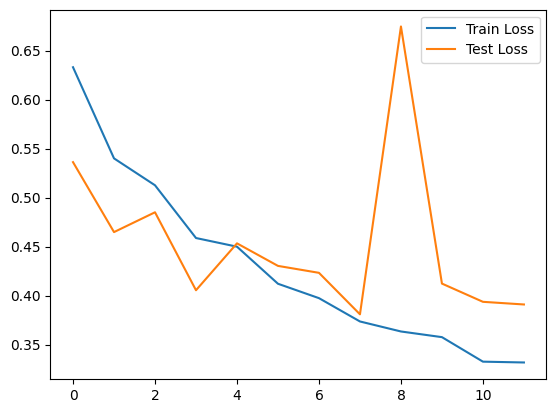

In [36]:
plt.plot(plot_avg_train_loss,label="Train Loss")
plt.plot(plot_avg_test_loss,label="Test Loss")
plt.legend()
plt.savefig("Loss_plot.png")

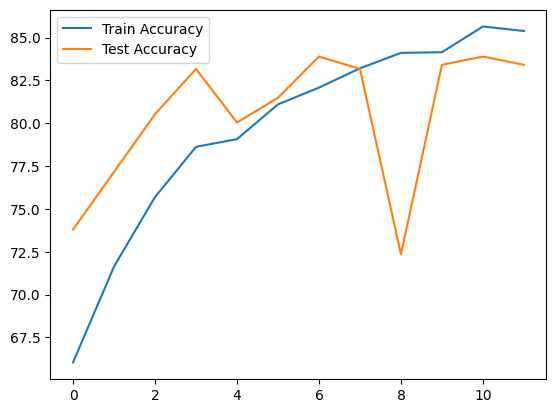

In [37]:
plt.plot(plot_avg_train_accs,label="Train Accuracy")
plt.plot(plot_avg_test_accs,label="Test Accuracy")
plt.legend()
plt.savefig("accuracy_plot.png")